# Notebook 01: Read and Validate ATL10 V7 (All 6 Beams)

This notebook validates that `read_atl10_v7()` correctly reads ATL10 V7 files
from your Gadi data directory, loads all 6 beams, and applies Antarctic filtering.

**Run this first** to confirm your environment and data paths are working.

In [1]:
import os
print(os.getcwd())
print(os.listdir('.'))

/home/581/xl1657
['ondemand', '.ssh', '.config', '.bashrc', '.bash_profile', '.jupyter-root', '.local', '.ipython', '.jupyter', '.bash_history', '.singularity', '.cache', '.viminfo', '.Xauthority', '.python_history', '.keras', 'my_env', '.vnc', '.dbus', 'Desktop', '.ICEauthority', 'untitled folder', '.copernicusmarine', 'cmems_adt', 'cmems_so.o162514369', 'cryo2ice_env']


## 1.1 Setup and Imports

In [2]:
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add notebooks directory to path so we can import utils
sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')
from utils import read_atl10_v7

print('All imports successful')


All imports successful


## 1.2 Define Data Paths

Update `DATA_DIR` if your ATL10 files are in a different location.

In [3]:
# Path to your ATL10 V7 files on Gadi
DATA_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/data/raw/ATL10'

# Find all .h5 files (recursive search through subdirectories)
files = sorted(glob.glob(f'{DATA_DIR}/**/*.h5', recursive=True))

# If no files found with recursive, try flat directory
if not files:
    files = sorted(glob.glob(f'{DATA_DIR}/*.h5'))

print(f'Found {len(files)} ATL10 V7 files')
print(f'First file: {files[0]}')
print(f'Last file:  {files[-1]}')


Found 8957 ATL10 V7 files
First file: /g/data/gv90/xl1657/phd/M2_workspace/data/raw/ATL10/ATL10-02_20220801023714_06141601_007_01.h5
Last file:  /g/data/gv90/xl1657/phd/M2_workspace/data/raw/ATL10/ATL10-02_20250911222602_13472801_007_01.h5


In [4]:
import h5py

# Inspect the actual HDF5 structure of your first file
with h5py.File(files[0], 'r') as f:
    print("=== Top-level groups ===")
    for key in f.keys():
        print(f"  {key}")
    
    print("\n=== Orbit info ===")
    sc = f['orbit_info/sc_orient'][:]
    print(f"  sc_orient: {sc}")
    
    # Check what's inside the first beam group
    beam = 'gt1r'
    print(f"\n=== {beam} subgroups ===")
    if beam in f:
        for key in f[beam].keys():
            print(f"  {beam}/{key}")
        
        # Check if freeboard_segment exists
        if 'freeboard_segment' in f[beam]:
            print(f"\n=== {beam}/freeboard_segment contents ===")
            for key in f[beam]['freeboard_segment'].keys():
                print(f"  {key}")
            # Try reading latitude
            try:
                lat = f[f'{beam}/freeboard_segment/latitude'][:]
                print(f"\n  latitude: {len(lat)} values, range [{lat.min():.2f}, {lat.max():.2f}]")
            except Exception as e:
                print(f"\n  latitude read error: {e}")
        else:
            print(f"\n  freeboard_segment NOT found. Available:")
            f[beam].visit(lambda name: print(f"    {name}"))
    else:
        print(f"  {beam} NOT found")

=== Top-level groups ===
  ancillary_data
  orbit_info
  quality_assessment
  METADATA
  gt1l
  gt1r
  gt2l
  gt2r
  gt3l
  gt3r

=== Orbit info ===
  sc_orient: [1]

=== gt1r subgroups ===
  gt1r/freeboard_segment
  gt1r/leads
  gt1r/reference_surface_section

=== gt1r/freeboard_segment contents ===
  beam_fb_confidence
  beam_fb_height
  beam_fb_quality_flag
  beam_fb_refsurf_interp
  beam_fb_unc
  beam_refsurf_ndx
  delta_time
  geoseg_beg
  geoseg_end
  height_segment_id
  latitude
  longitude
  seg_dist_x
  geophysical
  heights

  latitude: 10985 values, range [-70.72, -61.56]


In [5]:
import h5py
import numpy as np

with h5py.File(files[0], 'r') as f:
    beam = 'gt1r'
    grp = f'{beam}/freeboard_segment'
    
    qf = f[f'{grp}/beam_fb_quality_flag'][:]
    fb = f[f'{grp}/beam_fb_height'][:]
    lat = f[f'{grp}/latitude'][:]
    
    print(f"Quality flag unique values: {np.unique(qf)}")
    print(f"Quality flag == 0: {(qf == 0).sum()} / {len(qf)}")
    print(f"Quality flag == 1: {(qf == 1).sum()} / {len(qf)}")
    print()
    print(f"Freeboard range: {np.nanmin(fb):.3f} to {np.nanmax(fb):.3f}")
    print(f"Freeboard valid (-0.5 to 5.0): {((fb > -0.5) & (fb < 5.0)).sum()}")
    print(f"Latitude < -50: {(lat < -50).sum()}")
    print()
    print(f"Combined (qf==0 & fb valid & lat): "
          f"{((qf == 0) & (fb > -0.5) & (fb < 5.0) & (lat < -50)).sum()}")
    print(f"Combined (qf<=1 & fb valid & lat): "
          f"{((qf <= 1) & (fb > -0.5) & (fb < 5.0) & (lat < -50)).sum()}")
    print(f"Combined (fb valid & lat, no qf): "
          f"{((fb > -0.5) & (fb < 5.0) & (lat < -50)).sum()}")

Quality flag unique values: [1 2 3 4]
Quality flag == 0: 0 / 10985
Quality flag == 1: 10699 / 10985

Freeboard range: 0.000 to 340282346638528859811704183484516925440.000
Freeboard valid (-0.5 to 5.0): 5166
Latitude < -50: 10985

Combined (qf==0 & fb valid & lat): 0
Combined (qf<=1 & fb valid & lat): 5085
Combined (fb valid & lat, no qf): 5166


## 1.3 Test on a Single File

Read one file to verify the ATL10 V7 structure is read correctly.
All 6 beams should be loaded with proper beam_id and beam_type tags.

In [6]:
# Read a single file — all 6 beams loaded by default
df_test = read_atl10_v7(files[0])

print(f'Total segments (all 6 beams): {len(df_test)}')
print(f'Columns: {list(df_test.columns)}')
print()

# Check latitude range — should be < -50 for Antarctic
print(f'Lat range: {df_test.lat.min():.2f} to {df_test.lat.max():.2f}')
print(f'Lon range: {df_test.lon.min():.2f} to {df_test.lon.max():.2f}')
print()

# Freeboard statistics
print(f'Freeboard median: {df_test.fb.median():.4f} m')
print(f'Freeboard mean:   {df_test.fb.mean():.4f} m')
print(f'Freeboard std:    {df_test.fb.std():.4f} m')


Total segments (all 6 beams): 33784
Columns: ['lat', 'lon', 'fb', 'fb_unc', 'delta_time', 'beam_id', 'beam_name', 'beam_type']

Lat range: -70.61 to -61.11
Lon range: -92.67 to 81.79

Freeboard median: 0.2887 m
Freeboard mean:   0.3308 m
Freeboard std:    0.2368 m


## 1.4 Beam Breakdown

Verify that all 6 beams are present and check strong vs weak counts.
Strong beams typically have ~2x more segments than weak beams.

In [7]:
# Beam type breakdown
print('=== Beam Type Breakdown ===')
print(df_test.groupby('beam_type').size())
print()

# Individual beam breakdown
print('=== Individual Beam Breakdown ===')
beam_counts = df_test.groupby(['beam_name', 'beam_type', 'beam_id']).size()
print(beam_counts)


=== Beam Type Breakdown ===
beam_type
strong    20478
weak      13306
dtype: int64

=== Individual Beam Breakdown ===
beam_name  beam_type  beam_id
gt1l       weak       6           2362
gt1r       strong     5           5085
gt2l       weak       4           7265
gt2r       strong     3          10521
gt3l       weak       2           3679
gt3r       strong     1           4872
dtype: int64


## 1.5 Quick Visualisation

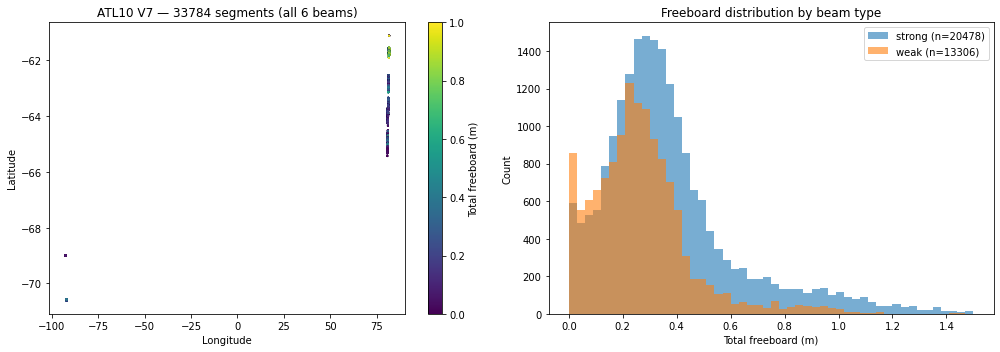

Figure saved.


In [8]:
import os
os.makedirs('/g/data/gv90/xl1657/phd/M2_workspace/output/figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter plot of IS2 segment locations
ax = axes[0]
sc = ax.scatter(df_test.lon, df_test.lat, c=df_test.fb,
                s=1, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='Total freeboard (m)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'ATL10 V7 — {len(df_test)} segments (all 6 beams)')

# Right: freeboard histogram by beam type
ax = axes[1]
for bt in ['strong', 'weak']:
    subset = df_test[df_test.beam_type == bt]
    ax.hist(subset.fb, bins=50, alpha=0.6, label=f'{bt} (n={len(subset)})',
            range=(0, 1.5))
ax.set_xlabel('Total freeboard (m)')
ax.set_ylabel('Count')
ax.legend()
ax.set_title('Freeboard distribution by beam type')

plt.tight_layout()
plt.savefig('/g/data/gv90/xl1657/phd/M2_workspace/output/figures/01_atl10_v7_validation.png', dpi=300)
plt.show()
print('Figure saved.')


## 1.6 Validation Assertions

These will raise errors if something is wrong.

In [9]:
# All latitudes should be Antarctic
assert df_test.lat.max() < -50, f'ERROR: Non-Antarctic data! Max lat = {df_test.lat.max()}'

# Should have both strong and weak beams
assert 'strong' in df_test.beam_type.values, 'ERROR: No strong beams found'
assert 'weak' in df_test.beam_type.values, 'ERROR: No weak beams found'

# Should have beam_ids 1–6
assert set(df_test.beam_id.unique()) == {1,2,3,4,5,6}, 'ERROR: Missing beam IDs'

# Freeboards should be physically reasonable
assert df_test.fb.median() > 0, 'ERROR: Median freeboard is negative'
assert df_test.fb.median() < 2.0, 'ERROR: Median freeboard unreasonably high'

print('ALL VALIDATIONS PASSED')


ALL VALIDATIONS PASSED


## 1.7 Batch Test: Read All August 2022 Files

Test reading multiple files to check consistency and estimate processing time.

In [10]:
import time

aug_files = [f for f in files if '202208' in f]
print(f'August 2022 files: {len(aug_files)}')

t0 = time.time()
total_segs = 0
total_strong = 0
total_weak = 0
files_with_data = 0

for i, f in enumerate(aug_files):
    df = read_atl10_v7(f)
    if len(df) > 0:
        total_segs += len(df)
        total_strong += (df.beam_type == 'strong').sum()
        total_weak += (df.beam_type == 'weak').sum()
        files_with_data += 1
    del df  # free memory immediately

    if (i + 1) % 50 == 0:
        print(f'  Processed {i+1}/{len(aug_files)} files... '
              f'({total_segs} segments so far)')

elapsed = time.time() - t0

print(f'\nAugust 2022 summary:')
print(f'  Files read: {len(aug_files)}')
print(f'  Files with data: {files_with_data}')
print(f'  Total segments: {total_segs}')
print(f'  Strong: {total_strong}')
print(f'  Weak:   {total_weak}')
print(f'  Time: {elapsed:.1f} seconds')

August 2022 files: 346
  Beam gt3l not found: 'Unable to synchronously open object (component not found)'
  Beam gt3l not found: 'Unable to synchronously open object (component not found)'
  Beam gt2l not found: 'Unable to synchronously open object (component not found)'
  Beam gt1l not found: 'Unable to synchronously open object (component not found)'
  Beam gt3l not found: 'Unable to synchronously open object (component not found)'
  Beam gt3l not found: 'Unable to synchronously open object (component not found)'
  Beam gt1l not found: 'Unable to synchronously open object (component not found)'
  Beam gt1l not found: 'Unable to synchronously open object (component not found)'
  Processed 50/346 files... (16156898 segments so far)
  Beam gt1l not found: 'Unable to synchronously open object (component not found)'
  Beam gt3l not found: 'Unable to synchronously open object (component not found)'
  Beam gt1l not found: 'Unable to synchronously open object (component not found)'
  Beam gt